# 17 — Inference with the small KITTI fusion model

This notebook reloads the 16-sample fusion checkpoint created by notebook 16 and verifies the complete inference path:

```text
KITTI LiDAR + image + calibration
              ↓
       fused BEV (7,H,W)
              ↓
        fusion detector
              ↓
     decoded BEV car boxes
```

**Important:** evaluation is performed on the same 16 frames used for training. It measures memorization and pipeline correctness, not generalization or test-set accuracy.

## 1. Imports and setup

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

CURRENT_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIRECTORY if (CURRENT_DIRECTORY / "src").is_dir() else CURRENT_DIRECTORY.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset.kitti_dataset import KittiDataset
from src.geometry.boxes import box_corners_from_parameters, get_lidar_boxes
from src.geometry.transforms import lidar_xy_to_bev
from src.inference.decode import decode_predictions
from src.models.bev_detector import BEVDetector
from src.preprocessing.fusion import build_fused_bev

## 2. Reload the checkpoint using its saved input metadata

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = PROJECT_ROOT / "outputs" / "bev_detector_fusion_small.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False,
)
config = checkpoint["config"]

print("Checkpoint:", checkpoint_path)
print("Input mode:", config["input_mode"])
print("Input channels:", config["input_channels"])
print("Epochs:", config["epochs"])
print("Training samples:", config["train_samples"])
print("Device:", device)

assert config["input_mode"] == "fusion"
assert config["input_channels"] == 7

model = BEVDetector(
    input_channels=config["input_channels"]
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Checkpoint loaded successfully.")

Checkpoint: /home/rahul/projects/kitti-lidar-detector/outputs/bev_detector_fusion_small.pth
Input mode: fusion
Input channels: 7
Epochs: 20
Training samples: 16
Device: cuda
Checkpoint loaded successfully.


In [3]:
dataset = KittiDataset(
    root=PROJECT_ROOT / "data" / "KITTI",
    split="training",
    load_images=True,
)

training_indices = checkpoint["split"]["train_indices"]
validation_indices = checkpoint["split"]["validation_indices"]

print("Training indices:", training_indices)
print("Validation indices:", validation_indices)
assert len(training_indices) == 16
assert validation_indices == []

Training indices: [5593, 5948, 7164, 1727, 5932, 232, 5501, 4463, 5994, 2626, 7050, 5955, 2622, 3339, 4439, 4635]
Validation indices: []


## 3. Inference helper

The score threshold is set to `0.10` because this deliberately tiny model has only seen 16 frames. This diagnostic threshold must be tuned on a real validation set after full training.

In [4]:
SCORE_THRESHOLD = 0.10
TOP_K = 50
MIN_CENTER_DISTANCE = 1.5


def infer_sample(sample_index):
    sample = dataset[sample_index]
    fused_bev = build_fused_bev(
        points=sample["points"],
        image=sample["image"],
        calibration=sample["calib"],
    )
    inputs = (
        torch.from_numpy(fused_bev)
        .unsqueeze(0)
        .float()
        .to(device)
    )

    with torch.no_grad():
        outputs = model(inputs)

    detections = decode_predictions(
        outputs,
        score_threshold=SCORE_THRESHOLD,
        top_k=TOP_K,
        min_center_distance=MIN_CENTER_DISTANCE,
    )
    ground_truth = get_lidar_boxes(
        sample["labels"],
        sample["calib"],
    )
    maximum_score = torch.sigmoid(
        outputs["heatmap"]
    ).max().item()

    return {
        "index": sample_index,
        "sample": sample,
        "fused_bev": fused_bev,
        "detections": detections,
        "ground_truth": ground_truth,
        "maximum_score": maximum_score,
    }

## 4. Run inference on all 16 memorized frames

In [5]:
results = [
    infer_sample(sample_index)
    for sample_index in training_indices
]

for result in results:
    print(
        f"sample={result['sample']['id']}",
        f"GT={len(result['ground_truth'])}",
        f"predictions={len(result['detections'])}",
        f"max_score={result['maximum_score']:.3f}",
    )

sample=005593 GT=1 predictions=1 max_score=0.174
sample=005948 GT=16 predictions=16 max_score=0.192
sample=007164 GT=2 predictions=3 max_score=0.206
sample=001727 GT=1 predictions=1 max_score=0.197
sample=005932 GT=6 predictions=6 max_score=0.193
sample=000232 GT=1 predictions=1 max_score=0.210
sample=005501 GT=5 predictions=5 max_score=0.210
sample=004463 GT=4 predictions=4 max_score=0.204
sample=005994 GT=1 predictions=1 max_score=0.203
sample=002626 GT=3 predictions=3 max_score=0.196
sample=007050 GT=6 predictions=6 max_score=0.190
sample=005955 GT=2 predictions=2 max_score=0.193
sample=002622 GT=4 predictions=3 max_score=0.212
sample=003339 GT=0 predictions=0 max_score=0.065
sample=004439 GT=3 predictions=3 max_score=0.189
sample=004635 GT=4 predictions=4 max_score=0.200


## 5. Diagnostic center-based metrics

A prediction counts as a true positive when its center lies within 2 metres of an unmatched ground-truth center. This is the same lightweight diagnostic used during training; it is **not** official KITTI Average Precision.

In [6]:
MATCH_DISTANCE = 2.0
true_positives = 0
false_positives = 0
false_negatives = 0

for result in results:
    ground_truth = result["ground_truth"]
    unmatched = set(range(len(ground_truth)))

    for detection in result["detections"]:
        candidates = [
            (
                math.hypot(
                    detection["center_x"] - ground_truth[index]["center_x"],
                    detection["center_y"] - ground_truth[index]["center_y"],
                ),
                index,
            )
            for index in unmatched
        ]

        if candidates:
            distance, matched_index = min(candidates)
        else:
            distance, matched_index = math.inf, None

        if distance <= MATCH_DISTANCE:
            true_positives += 1
            unmatched.remove(matched_index)
        else:
            false_positives += 1

    false_negatives += len(unmatched)

precision = true_positives / max(1, true_positives + false_positives)
recall = true_positives / max(1, true_positives + false_negatives)
f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0
    else 0.0
)

print("True positives:", true_positives)
print("False positives:", false_positives)
print("False negatives:", false_negatives)
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 score:  {f1:.3f}")

True positives: 58
False positives: 1
False negatives: 1
Precision: 0.983
Recall:    0.983
F1 score:  0.983


## 6. Plot ground truth versus predictions

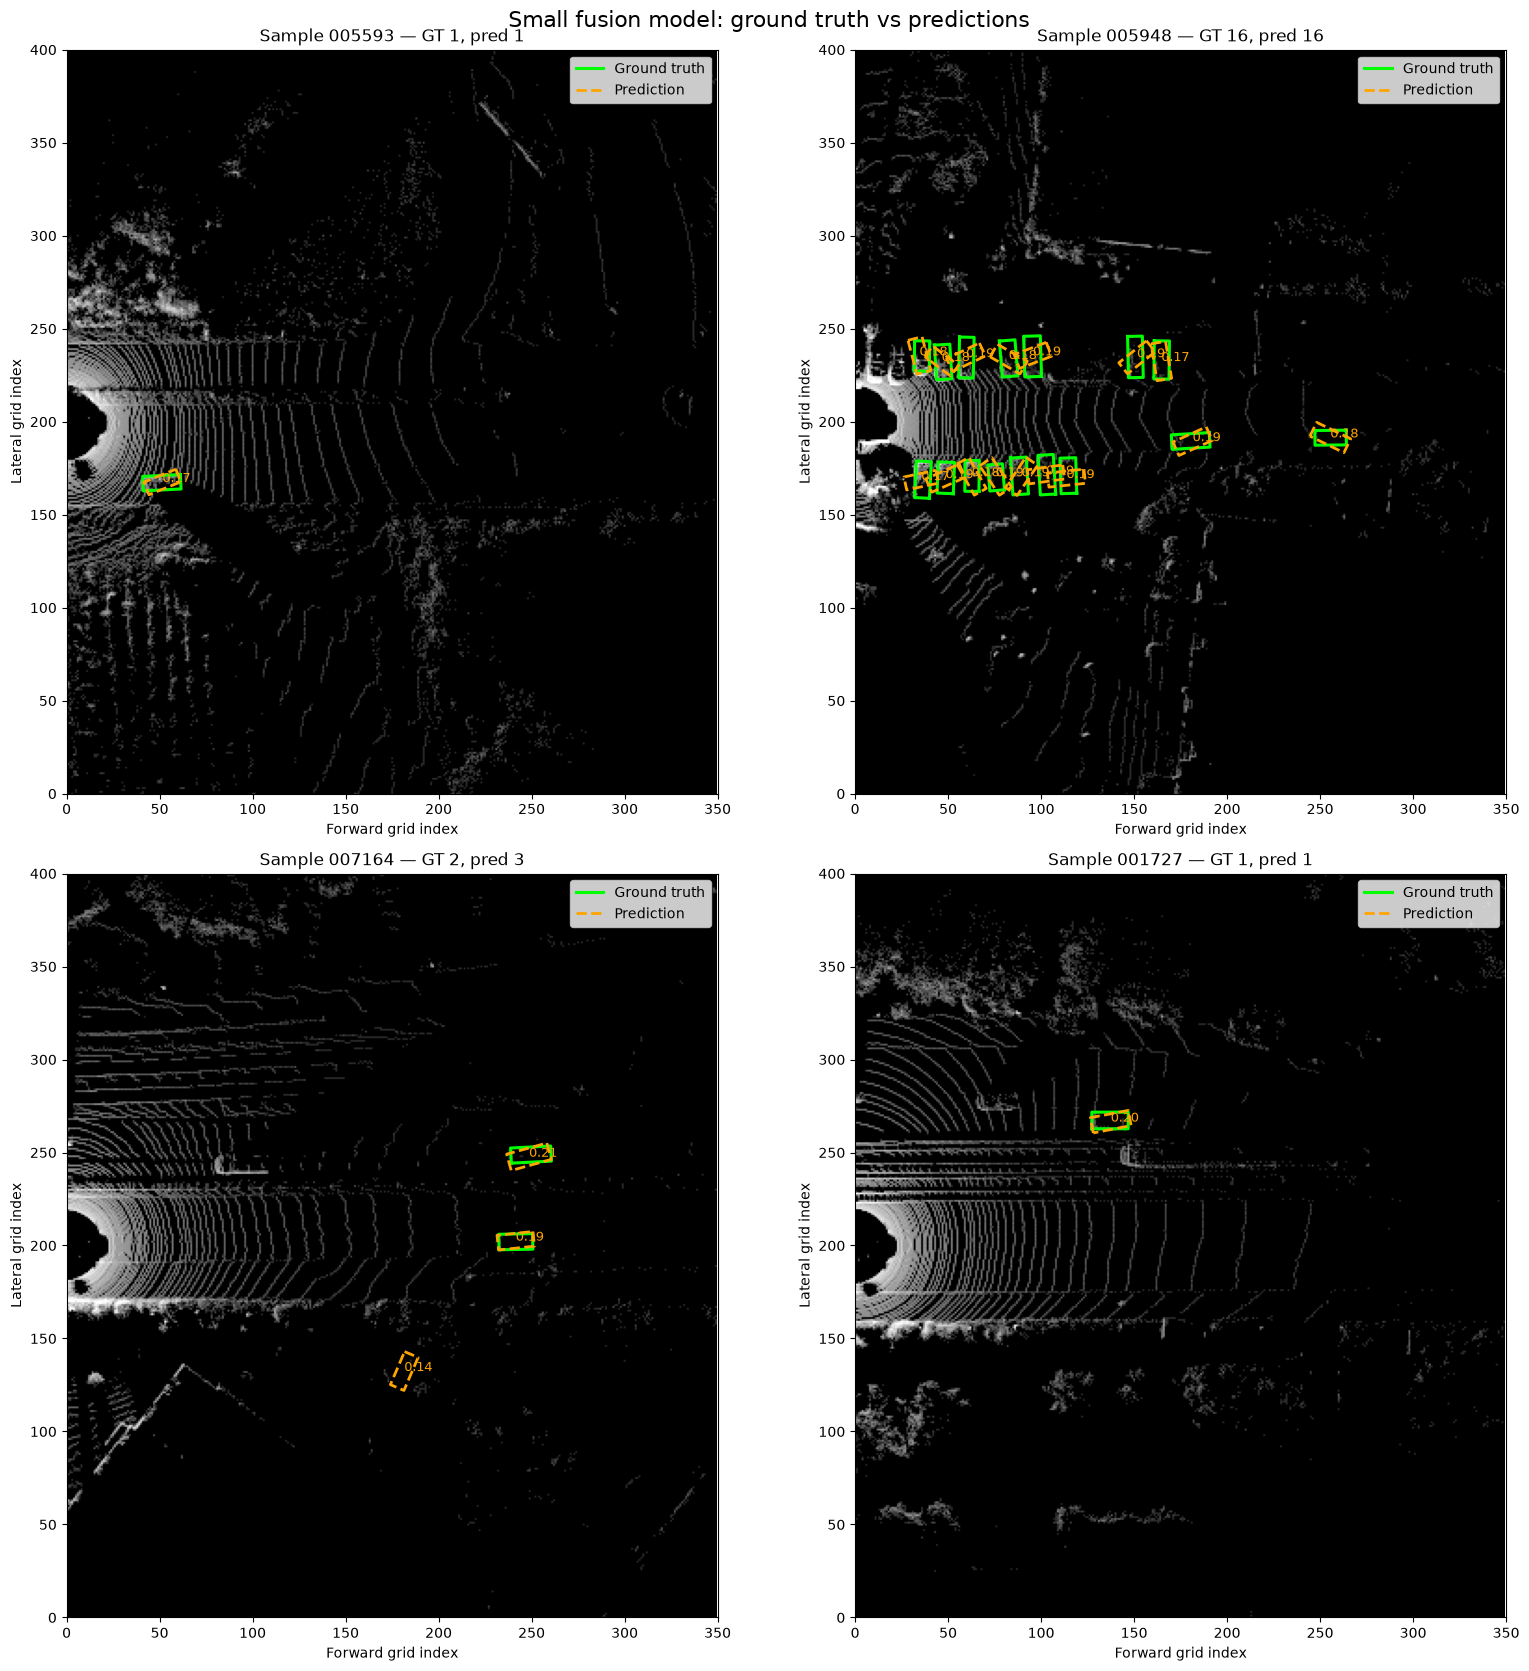

In [7]:
def draw_box(ax, box, color, linestyle, label=None, linewidth=2.0):
    corners = box_corners_from_parameters(
        box["center_x"],
        box["center_y"],
        box["length"],
        box["width"],
        box["yaw"],
    )
    corners_bev = lidar_xy_to_bev(corners)
    closed = np.vstack((corners_bev, corners_bev[0]))
    ax.plot(
        closed[:, 0],
        closed[:, 1],
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        label=label,
    )


display_results = results[:4]
fig, axes = plt.subplots(2, 2, figsize=(16, 17))

for ax, result in zip(axes.flat, display_results):
    ax.imshow(
        result["fused_bev"][1].T,
        origin="lower",
        cmap="gray",
        aspect="equal",
    )

    for index, box in enumerate(result["ground_truth"]):
        draw_box(
            ax,
            box,
            color="lime",
            linestyle="-",
            label="Ground truth" if index == 0 else None,
            linewidth=2.2,
        )

    for index, detection in enumerate(result["detections"]):
        draw_box(
            ax,
            detection,
            color="orange",
            linestyle="--",
            label="Prediction" if index == 0 else None,
        )
        center = lidar_xy_to_bev(
            np.array([[
                detection["center_x"],
                detection["center_y"],
            ]])
        )[0]
        ax.text(
            center[0],
            center[1],
            f"{detection['score']:.2f}",
            color="orange",
            fontsize=9,
        )

    ax.set_xlim(0, result["fused_bev"].shape[1])
    ax.set_ylim(0, result["fused_bev"].shape[2])
    ax.set_xlabel("Forward grid index")
    ax.set_ylabel("Lateral grid index")
    ax.set_title(
        f"Sample {result['sample']['id']} — "
        f"GT {len(result['ground_truth'])}, "
        f"pred {len(result['detections'])}"
    )
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="upper right")

fig.suptitle(
    "Small fusion model: ground truth vs predictions",
    fontsize=16,
)
fig.tight_layout()
plt.show()

## 7. Inspect the training-loss curve stored in the checkpoint

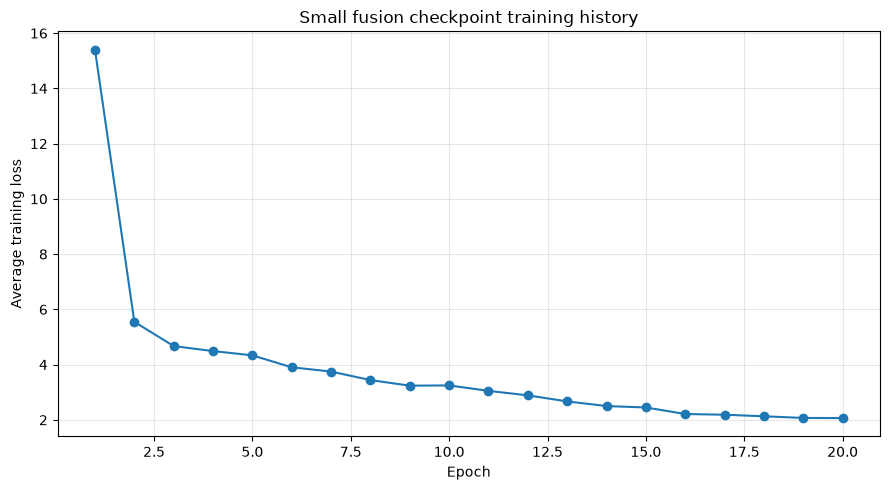

First loss: 15.3991
Best loss:  2.0639
Final loss: 2.0639


In [8]:
history = checkpoint["history"]
epochs = [record["epoch"] for record in history]
losses = [record["train"]["total"] for record in history]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, losses, marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average training loss")
ax.set_title("Small fusion checkpoint training history")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"First loss: {losses[0]:.4f}")
print(f"Best loss:  {min(losses):.4f}")
print(f"Final loss: {losses[-1]:.4f}")

## Interpretation

Passing this notebook means:

- the checkpoint records the correct seven-channel configuration;
- the model can be reconstructed without guessing its input shape;
- inference rebuilds the same fused representation used during training;
- decoding produces valid metric boxes;
- predictions and ground truth can be inspected in the shared BEV frame.

It does not establish generalization because the checkpoint used no validation samples. The next experiment is a 100–300 sample run with a held-out validation split, followed by the controlled full LiDAR-versus-fusion comparison.